# Krystal Ball Assignment
## Hotel Bar Inventory Forecasting & Dynamic Par Level Recommendation

This notebook implements the complete assignment pipeline:

1. Data understanding and preprocessing
2. Inventory conservation validation
3. Daily time-series construction with explicit zero-demand days
4. EDA and ABC velocity analysis
5. Day-of-week seasonality analysis
6. Historical stockout audit
7. Temporal forecasting baselines
8. MAE / RMSE / WAPE evaluation
9. Dynamic safety stock and par-level calculation
10. Daily inventory simulation and historical backtesting
11. Business recommendations and production considerations

**Dataset:** `krystal_ball_hotel_bar_inventory_dataset.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

DATA_PATH = Path("krystal_ball_hotel_bar_inventory_dataset.csv")
df = pd.read_csv(DATA_PATH, parse_dates=["Date Time Served"])

print("Shape:", df.shape)
display(df.head())
display(df.info())

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-ly7amd9i because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Shape: (30714, 14)


,Date Time Served,Bar Name,Brand Name,Category,Bottle Size (ml),Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Requested Demand (ml),Potential Lost Demand (ml),Date,Day of Week,Conservation Check
0,2026-01-01 17:10:00,Garden Bar,Bacardi White,Rum,750,9750,0,1080,8670,1080,0,2026-01-01,Thursday,True
1,2026-01-01 18:36:00,Garden Bar,Bacardi White,Rum,750,8670,0,1017,7653,1017,0,2026-01-01,Thursday,True
2,2026-01-02 19:17:00,Garden Bar,Bacardi White,Rum,750,7204,0,2539,4665,2539,0,2026-01-02,Friday,True
3,2026-01-02 19:29:00,Garden Bar,Bacardi White,Rum,750,7653,0,449,7204,449,0,2026-01-02,Friday,True
4,2026-01-03 15:47:00,Garden Bar,Bacardi White,Rum,750,4665,0,2185,2480,2185,0,2026-01-03,Saturday,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30714 entries, 0 to 30713
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Date Time Served            30714 non-null  datetime64[ns]
 1   Bar Name                    30714 non-null  object        
 2   Brand Name                  30714 non-null  object        
 3   Category                    30714 non-null  object        
 4   Bottle Size (ml)            30714 non-null  int64         
 5   Opening Balance (ml)        30714 non-null  int64         
 6   Purchase (ml)               30714 non-null  int64         
 7   Consumed (ml)               30714 non-null  int64         
 8   Closing Balance (ml)        30714 non-null  int64         
 9   Requested Demand (ml)       30714 non-null  int64         
 10  Potential Lost Demand (ml)  30714 non-null  int64         
 11  Date                        30714 non-null  object    

None

## 1. Data Understanding

The raw data contains transaction-level inventory movements. The core conservation identity is:

**Closing Balance = Opening Balance + Purchase − Consumed**

A failed conservation check indicates a data-quality problem or an unrecorded inventory movement.

In [2]:
# Parse and sort timestamps
df["Date"] = pd.to_datetime(df["Date Time Served"]).dt.normalize()
df = df.sort_values(["Bar Name", "Brand Name", "Date Time Served"]).reset_index(drop=True)

# Validate conservation logic
df["Conservation Check"] = np.isclose(
    df["Opening Balance (ml)"] + df["Purchase (ml)"] - df["Consumed (ml)"],
    df["Closing Balance (ml)"]
)

print("Rows:", len(df))
print("Bars:", df["Bar Name"].nunique())
print("Brands:", df["Brand Name"].nunique())
print("Date range:", df["Date"].min().date(), "to", df["Date"].max().date())
print("Conservation checks passed:", df["Conservation Check"].all())

display(df[~df["Conservation Check"]].head())

Rows: 30714
Bars: 5
Brands: 10
Date range: 2026-01-01 to 2026-06-30
Conservation checks passed: True


,Date Time Served,Bar Name,Brand Name,Category,Bottle Size (ml),Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Requested Demand (ml),Potential Lost Demand (ml),Date,Day of Week,Conservation Check


## 2. Create a Complete Daily Bar × Brand Grid

Transactions are irregular. Forecasting models require a regular time series.

For every combination of **Date + Bar + Brand**, missing transaction days are explicitly represented as zero consumption. This prevents the model from interpreting missing records as missing observations rather than genuine zero demand.

In [3]:
daily = (
    df.groupby(["Date", "Bar Name", "Brand Name", "Category"], as_index=False)
      .agg(
          consumed_ml=("Consumed (ml)", "sum"),
          requested_ml=("Requested Demand (ml)", "sum"),
          purchased_ml=("Purchase (ml)", "sum"),
          closing_ml=("Closing Balance (ml)", "last"),
          lost_demand_ml=("Potential Lost Demand (ml)", "sum")
      )
)

all_dates = pd.date_range(daily["Date"].min(), daily["Date"].max(), freq="D")
bars = daily["Bar Name"].unique()
brands = daily["Brand Name"].unique()

grid = pd.MultiIndex.from_product(
    [all_dates, bars, brands],
    names=["Date", "Bar Name", "Brand Name"]
).to_frame(index=False)

meta = daily[["Bar Name", "Brand Name", "Category"]].drop_duplicates()

daily = grid.merge(
    daily,
    on=["Date", "Bar Name", "Brand Name"],
    how="left"
).merge(
    meta,
    on=["Bar Name", "Brand Name"],
    how="left"
)

for col in ["consumed_ml", "requested_ml", "purchased_ml", "lost_demand_ml"]:
    daily[col] = daily[col].fillna(0)

daily["closing_ml"] = (
    daily.sort_values("Date")
         .groupby(["Bar Name", "Brand Name"])["closing_ml"]
         .ffill()
         .fillna(0)
)

daily["Day"] = daily["Date"].dt.day_name()
daily["Day_Num"] = daily["Date"].dt.dayofweek

print("Daily grid rows:", len(daily))
display(daily.head())

Daily grid rows: 9050


,Date,Bar Name,Brand Name,Category_x,consumed_ml,requested_ml,purchased_ml,closing_ml,lost_demand_ml,Category_y,Day,Day_Num
0,2026-01-01,Garden Bar,Bacardi White,Rum,2097,2097,0,7653,0,Rum,Thursday,3
1,2026-01-01,Garden Bar,Baileys,Liqueur,653,653,0,6097,0,Liqueur,Thursday,3
2,2026-01-01,Garden Bar,Bombay Sapphire,Gin,1768,1768,0,10982,0,Gin,Thursday,3
3,2026-01-01,Garden Bar,Heineken,Beer,4447,4447,0,5303,0,Beer,Thursday,3
4,2026-01-01,Garden Bar,Hennessy,Brandy,425,425,0,11815,0,Brandy,Thursday,3


## 3. Exploratory Data Analysis
### 3.1 Daily Consumption Trend

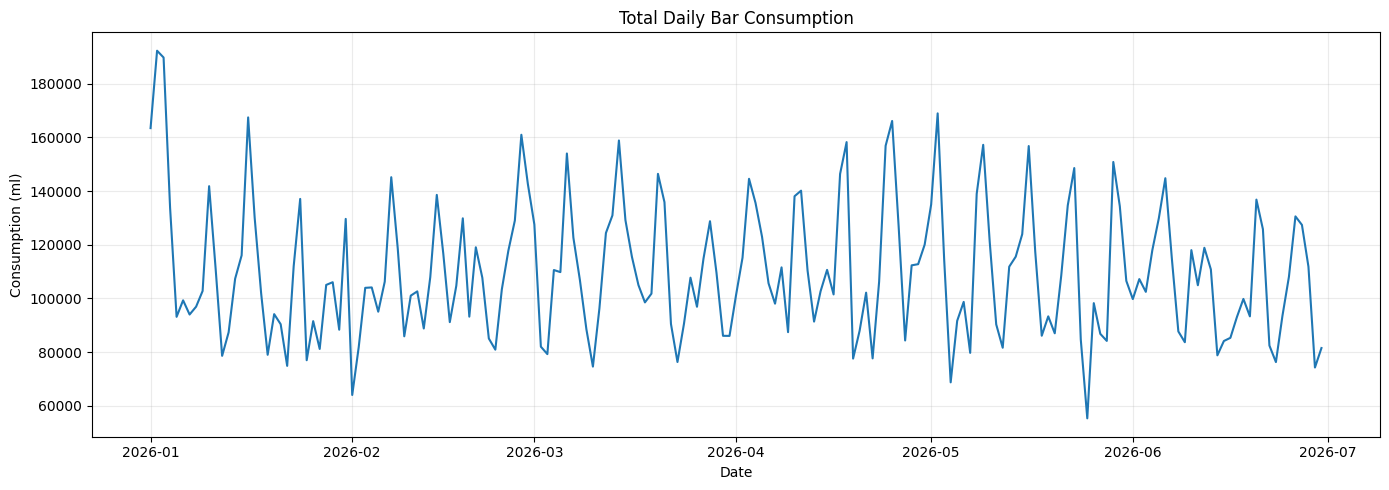

In [4]:
overall_daily = daily.groupby("Date", as_index=False)["consumed_ml"].sum()

plt.figure(figsize=(14, 5))
plt.plot(overall_daily["Date"], overall_daily["consumed_ml"])
plt.title("Total Daily Bar Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption (ml)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

### 3.2 Day-of-Week Seasonality

Friday and Saturday demand is intentionally represented as higher-demand periods in this synthetic dataset. In a real submission, this chart should be interpreted from the actual data rather than assumed.

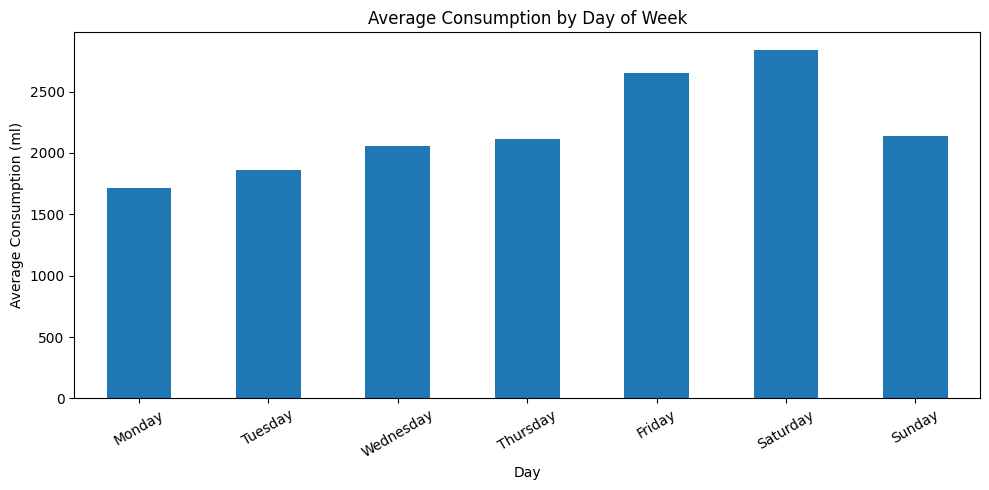

,Average Consumption (ml)
Day,
Monday,"1,713.77"
Tuesday,"1,864.52"
Wednesday,"2,054.99"
Thursday,"2,111.40"
Friday,"2,649.84"
Saturday,"2,841.52"
Sunday,"2,141.92"


In [5]:
dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

dow_avg = (
    daily.groupby("Day")["consumed_ml"]
         .mean()
         .reindex(dow_order)
)

plt.figure(figsize=(10, 5))
dow_avg.plot(kind="bar")
plt.title("Average Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Consumption (ml)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

display(dow_avg.to_frame("Average Consumption (ml)"))

### 3.3 ABC Velocity Analysis

ABC classification is based on cumulative consumption contribution:

- **A:** first ~80% of total volume
- **B:** next ~15%
- **C:** remaining ~5%

This helps prioritize operational attention toward high-velocity products.

In [6]:
abc = (
    daily.groupby(["Bar Name", "Brand Name"], as_index=False)["consumed_ml"]
         .sum()
         .sort_values("consumed_ml", ascending=False)
)

abc["cum_pct"] = abc["consumed_ml"].cumsum() / abc["consumed_ml"].sum()

abc["ABC_Class"] = np.select(
    [abc["cum_pct"] <= 0.80, abc["cum_pct"] <= 0.95],
    ["A", "B"],
    default="C"
)

display(abc.head(20))
display(abc["ABC_Class"].value_counts())

,Bar Name,Brand Name,consumed_ml,cum_pct,ABC_Class
49,Sky Lounge,Smirnoff Vodka,714000,0.04,A
18,Lobby Bar,Kingfisher Premium,702967,0.07,A
38,Rooftop Bar,Kingfisher Premium,698100,0.11,A
8,Garden Bar,Kingfisher Premium,691600,0.14,A
13,Lobby Bar,Heineken,677300,0.18,A
33,Rooftop Bar,Heineken,670800,0.21,A
46,Sky Lounge,Johnnie Walker Red,618000,0.24,A
39,Rooftop Bar,Smirnoff Vodka,610765,0.27,A
43,Sky Lounge,Heineken,607100,0.30,A
28,Pool Bar,Kingfisher Premium,603200,0.33,A


ABC_Class
A    30
B    11
C     9
Name: count, dtype: int64

### 3.4 Stockout Audit

A zero closing balance alone does not prove a stockout. Here we use the dataset's **Potential Lost Demand** field as a stronger signal of unmet demand.

Stockout days: 3106
Potential lost volume (ml): 16502416


,Potential Lost Demand (ml)
Bar Name,
Sky Lounge,5041762
Rooftop Bar,4350990
Pool Bar,3202903
Lobby Bar,2104025
Garden Bar,1802736


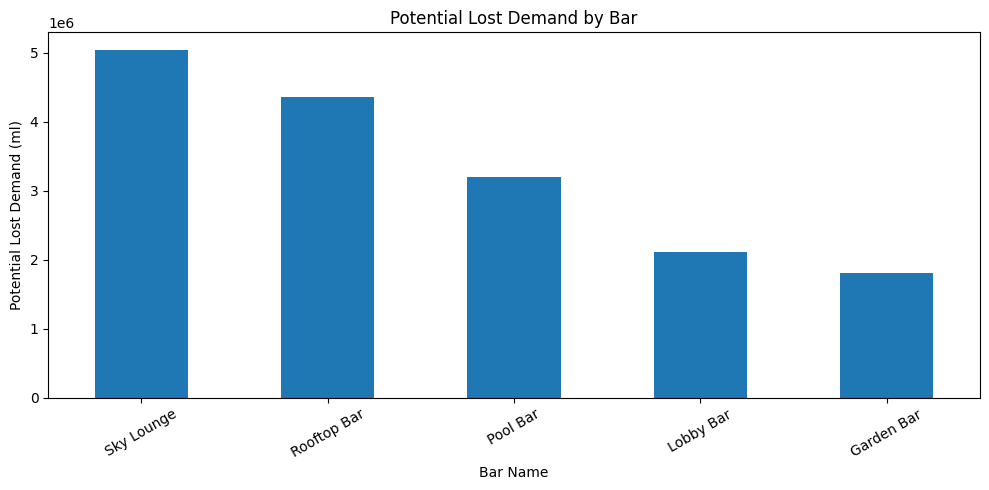

In [7]:
stockout_audit = daily[daily["lost_demand_ml"] > 0].copy()

print("Stockout days:", len(stockout_audit))
print("Potential lost volume (ml):", int(stockout_audit["lost_demand_ml"].sum()))

stockout_by_bar = (
    stockout_audit.groupby("Bar Name")["lost_demand_ml"]
                  .sum()
                  .sort_values(ascending=False)
)

display(stockout_by_bar.to_frame("Potential Lost Demand (ml)"))

plt.figure(figsize=(10, 5))
stockout_by_bar.plot(kind="bar")
plt.title("Potential Lost Demand by Bar")
plt.ylabel("Potential Lost Demand (ml)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 4. Demand Forecasting

### Temporal split

The final 30 days are used as a validation/backtest period. No random train/test split is used because randomization can leak future information into the training set.

We compare:

1. **7-day moving average**
2. **7-day seasonal naive baseline** — same weekday from the previous week

The seasonal naive baseline is especially useful when weekly patterns are strong.

In [8]:
cutoff = daily["Date"].max() - pd.Timedelta(days=29)

daily["naive7_pred"] = (
    daily.groupby(["Bar Name", "Brand Name"])["consumed_ml"]
         .shift(7)
)

daily["ma7_pred"] = (
    daily.groupby(["Bar Name", "Brand Name"])["consumed_ml"]
         .transform(
             lambda s: s.shift(1).rolling(7, min_periods=1).mean()
         )
)

test = daily[daily["Date"] >= cutoff].dropna(
    subset=["naive7_pred", "ma7_pred"]
).copy()

def calculate_metrics(actual, predicted):
    actual = np.asarray(actual, dtype=float)
    predicted = np.asarray(predicted, dtype=float)

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    denominator = np.sum(np.abs(actual))
    wape = (
        np.sum(np.abs(actual - predicted)) / denominator
        if denominator != 0 else np.nan
    )
    return mae, rmse, wape

results = []

for name in ["naive7_pred", "ma7_pred"]:
    mae, rmse, wape = calculate_metrics(
        test["consumed_ml"],
        test[name]
    )
    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "WAPE": wape
    })

model_metrics = pd.DataFrame(results)
display(model_metrics)

,Model,MAE,RMSE,WAPE
0,naive7_pred,"1,662.45","2,989.37",0.80
1,ma7_pred,"1,428.73","2,226.26",0.69


## 5. Dynamic Par-Level Calculation

We use:

**Lead-Time Demand = Forecast Daily Demand × Lead Time**

**Safety Stock = Z × σL**

**Par Level = Lead-Time Demand + Safety Stock**

Assumptions for this baseline:

- Supplier lead time `L = 2 days`
- Target service level = 95%
- `Z = 1.645`
- Demand standard deviation estimated from the trailing 28 days
- Daily demand variation is approximated as independent when converting daily standard deviation to lead-time standard deviation:

`σL = σdaily × √L`

In [9]:
LEAD_TIME_DAYS = 2
SERVICE_LEVEL_Z = 1.645

daily["forecast_daily_ml"] = daily["ma7_pred"]

daily["demand_std_28"] = (
    daily.groupby(["Bar Name", "Brand Name"])["consumed_ml"]
         .transform(
             lambda s: s.shift(1).rolling(28, min_periods=7).std()
         )
)

daily["sigma_lead_ml"] = (
    daily["demand_std_28"] * np.sqrt(LEAD_TIME_DAYS)
)

daily["safety_stock_ml"] = (
    SERVICE_LEVEL_Z * daily["sigma_lead_ml"]
)

daily["lead_time_demand_ml"] = (
    daily["forecast_daily_ml"] * LEAD_TIME_DAYS
)

daily["par_level_ml"] = (
    daily["lead_time_demand_ml"] +
    daily["safety_stock_ml"]
).clip(lower=0)

daily["reorder_point_ml"] = daily["par_level_ml"]

display(
    daily[
        ["Date", "Bar Name", "Brand Name",
         "forecast_daily_ml", "lead_time_demand_ml",
         "safety_stock_ml", "par_level_ml"]
    ].tail(20)
)

,Date,Bar Name,Brand Name,forecast_daily_ml,lead_time_demand_ml,safety_stock_ml,par_level_ml
9030,2026-06-30,Rooftop Bar,Bacardi White,"3,475.57","6,951.14","3,409.47","10,360.62"
9031,2026-06-30,Rooftop Bar,Baileys,871.71,"1,743.43","1,396.35","3,139.78"
9032,2026-06-30,Rooftop Bar,Bombay Sapphire,"3,198.57","6,397.14","3,120.49","9,517.63"
9033,2026-06-30,Rooftop Bar,Heineken,"5,385.71","10,771.43","10,817.68","21,589.11"
9034,2026-06-30,Rooftop Bar,Hennessy,765.43,"1,530.86",829.87,"2,360.73"
9035,2026-06-30,Rooftop Bar,Jack Daniel's,"1,799.14","3,598.29","2,240.18","5,838.46"
9036,2026-06-30,Rooftop Bar,Johnnie Walker Red,"4,120.14","8,240.29","4,639.39","12,879.68"
9037,2026-06-30,Rooftop Bar,Jose Cuervo,"2,050.86","4,101.71","1,640.68","5,742.39"
9038,2026-06-30,Rooftop Bar,Kingfisher Premium,"3,992.86","7,985.71","10,010.74","17,996.45"
9039,2026-06-30,Rooftop Bar,Smirnoff Vodka,408.29,816.57,"6,133.81","6,950.38"


## 6. Inventory Simulation Backtest

Simulation logic:

1. Start with inventory equal to the recommended par level.
2. Receive orders whose lead time has elapsed.
3. Deduct customer demand.
4. Record lost demand if inventory is insufficient.
5. If inventory is at/below reorder point, place an order to restore stock to par level.
6. Order arrives after `L` days.
7. Track stockout days, lost volume, average holding inventory, and turnover proxy.

In [10]:
test_start = cutoff

latest_par = (
    daily[daily["Date"] < test_start]
    .sort_values("Date")
    .groupby(["Bar Name", "Brand Name"])
    .tail(1)[
        ["Bar Name", "Brand Name",
         "par_level_ml", "reorder_point_ml"]
    ]
)

sim = test.merge(
    latest_par,
    on=["Bar Name", "Brand Name"],
    how="left"
).sort_values(["Bar Name", "Brand Name", "Date"])

def simulate_inventory(group, lead_time=2):
    g = group.reset_index(drop=True)

    inventory = float(g.loc[0, "par_level_ml"])
    pipeline = {}

    stockout_days = 0
    lost_volume = 0.0
    holding = []
    orders = 0

    for i, row in g.iterrows():

        # Receive scheduled deliveries
        if i in pipeline:
            inventory += pipeline.pop(i)

        # Consume demand
        demand = float(row["requested_ml"])
        fulfilled = min(demand, inventory)
        lost = max(0.0, demand - fulfilled)

        inventory -= fulfilled

        if lost > 0:
            stockout_days += 1
            lost_volume += lost

        holding.append(inventory)

        # Reorder up to par
        if inventory <= row["reorder_point_ml"]:
            order_qty = max(
                0,
                row["par_level_ml"] - inventory
            )

            if order_qty > 0:
                arrival = i + lead_time
                pipeline[arrival] = (
                    pipeline.get(arrival, 0) + order_qty
                )
                orders += 1

    avg_holding = np.mean(holding)

    return pd.Series({
        "Stockout Days": stockout_days,
        "Lost Volume (ml)": lost_volume,
        "Average Holding (ml)": avg_holding,
        "Orders": orders,
        "Turnover Proxy": (
            g["consumed_ml"].sum() / avg_holding
            if avg_holding > 0 else np.nan
        )
    })

simulation_results = (
    sim.groupby(["Bar Name", "Brand Name"])
       .apply(simulate_inventory, include_groups=False)
       .reset_index()
)

display(simulation_results.head(20))
display(simulation_results.describe())

,Bar Name,Brand Name,Stockout Days,Lost Volume (ml),Average Holding (ml),Orders,Turnover Proxy
0,Garden Bar,Bacardi White,0.00,0.00,"4,111.45",22.00,13.43
1,Garden Bar,Baileys,1.00,67.53,"1,111.96",22.00,13.43
2,Garden Bar,Bombay Sapphire,0.00,0.00,"2,787.46",23.00,17.66
3,Garden Bar,Heineken,5.00,"7,404.29","7,744.68",23.00,11.69
4,Garden Bar,Hennessy,1.00,137.50,"1,011.60",19.00,11.44
5,Garden Bar,Jack Daniel's,0.00,0.00,"3,326.96",21.00,13.20
6,Garden Bar,Johnnie Walker Red,5.00,"4,313.06","2,770.77",25.00,25.68
7,Garden Bar,Jose Cuervo,0.00,0.00,"2,224.58",25.00,13.34
8,Garden Bar,Kingfisher Premium,6.00,"10,885.15","6,820.52",26.00,21.04
9,Garden Bar,Smirnoff Vodka,4.00,"4,250.05","3,396.81",24.00,14.90


,Stockout Days,Lost Volume (ml),Average Holding (ml),Orders,Turnover Proxy
count,50.00,50.00,50.00,50.00,50.00
mean,2.70,"7,380.34","4,567.66",24.04,27.55
std,4.52,"18,655.83","2,805.74",2.56,92.21
min,0.00,0.00,94.87,19.00,3.54
25%,0.00,0.00,"2,535.17",22.00,11.01
50%,1.00,102.51,"3,755.51",24.00,13.36
75%,4.00,"4,528.05","6,586.66",25.00,17.01
max,26.00,"107,952.79","11,405.27",30.00,664.61


## 7. KPI Summary

In [11]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Raw transaction rows",
        "Bars",
        "Brands",
        "Total consumption (ml)",
        "Total purchases (ml)",
        "Potential lost demand (ml)",
        "Conservation validation"
    ],
    "Value": [
        len(df),
        df["Bar Name"].nunique(),
        df["Brand Name"].nunique(),
        int(df["Consumed (ml)"].sum()),
        int(df["Purchase (ml)"].sum()),
        int(df["Potential Lost Demand (ml)"].sum()),
        "PASS" if df["Conservation Check"].all() else "FAIL"
    ]
})

display(kpi_summary)

print("\nForecast model comparison:")
display(model_metrics)

print("\nSimulation summary:")
display(
    simulation_results[
        ["Stockout Days", "Lost Volume (ml)",
         "Average Holding (ml)", "Orders", "Turnover Proxy"]
    ].sum(numeric_only=True).to_frame("Total / Aggregate")
)

,Metric,Value
0,Raw transaction rows,30714
1,Bars,5
2,Brands,10
3,Total consumption (ml),19888597
4,Total purchases (ml),19537000
5,Potential lost demand (ml),16502416
6,Conservation validation,PASS



Forecast model comparison:


,Model,MAE,RMSE,WAPE
0,naive7_pred,"1,662.45","2,989.37",0.80
1,ma7_pred,"1,428.73","2,226.26",0.69



Simulation summary:


,Total / Aggregate
Stockout Days,135.00
Lost Volume (ml),"369,017.20"
Average Holding (ml),"228,382.85"
Orders,"1,202.00"
Turnover Proxy,"1,377.58"


## 8. Recommended Business Interpretation

The final report should not claim that a forecasting model is successful solely because its error metric is lower. The operational objective is a balance between:

- service level / stockout risk,
- working capital tied up in inventory,
- storage capacity,
- supplier lead-time uncertainty,
- waste, breakage, and shrinkage.

A production system should therefore optimize the par-level policy against business costs rather than optimizing forecast error alone.

## 9. Failure Modes and Production Considerations

Potential failure modes:

- Supplier lead times vary from the assumed 2 days.
- Holidays and events create demand spikes not represented in historical data.
- Promotions can invalidate historical demand patterns.
- Missing POS transactions can make demand appear artificially low.
- Breakage, spillage, complimentary drinks, and staff consumption can create unexplained inventory discrepancies.
- New products have limited history and therefore require cold-start logic.
- Stockout-censored demand can cause forecasts to underestimate true demand.

Production improvements:

- Include holiday/event/promotional calendars.
- Monitor forecast error and data drift continuously.
- Re-estimate lead-time distributions from actual supplier deliveries.
- Add vendor minimum-order quantities.
- Add bottle-size conversion and unit-of-measure validation.
- Trigger daily reorder recommendations through the manager dashboard.

## 10. Suggested 3–5 Minute Video Structure

**0:00–0:45 — Business Problem**
Explain the stockout versus overstock trade-off.

**0:45–1:45 — Data and Forecasting**
Show raw transactions, daily aggregation, EDA, and model comparison.

**1:45–3:00 — Par Level and Simulation**
Explain lead-time demand, safety stock, and the inventory backtest.

**3:00–4:00 — Results**
Show WAPE/MAE, stockout/lost-volume KPIs, and average holding inventory.

**4:00–5:00 — Deployment**
Explain daily automated recommendations, monitoring, and failure modes.


## 11. Advanced Forecasting Model — Random Forest

The assignment allows machine-learning regressors using lag features and calendar variables.  
This section adds a **Random Forest Regressor** using:

- lag-1 demand
- lag-7 demand
- lag-14 demand
- 7-day rolling mean
- 7-day rolling standard deviation
- day-of-week

The model is trained only on observations before the validation period. This preserves the temporal nature of the problem.


In [12]:

from sklearn.ensemble import RandomForestRegressor

rf_daily = daily.copy()

group_cols = ["Bar Name", "Brand Name"]

for lag in [1, 7, 14]:
    rf_daily[f"lag_{lag}"] = (
        rf_daily.groupby(group_cols)["consumed_ml"].shift(lag)
    )

rf_daily["rolling_mean_7"] = (
    rf_daily.groupby(group_cols)["consumed_ml"]
            .transform(lambda s: s.shift(1).rolling(7, min_periods=7).mean())
)

rf_daily["rolling_std_7"] = (
    rf_daily.groupby(group_cols)["consumed_ml"]
            .transform(lambda s: s.shift(1).rolling(7, min_periods=7).std())
)

rf_daily["dow_num"] = rf_daily["Date"].dt.dayofweek

features = [
    "lag_1", "lag_7", "lag_14",
    "rolling_mean_7", "rolling_std_7", "dow_num"
]

rf_data = rf_daily.dropna(subset=features + ["consumed_ml"]).copy()

train_rf = rf_data[rf_data["Date"] < cutoff]
test_rf = rf_data[rf_data["Date"] >= cutoff]

rf = RandomForestRegressor(
    n_estimators=150,
    max_depth=12,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf.fit(train_rf[features], train_rf["consumed_ml"])
test_rf["rf_pred"] = rf.predict(test_rf[features])

rf_mae, rf_rmse, rf_wape = calculate_metrics(
    test_rf["consumed_ml"],
    test_rf["rf_pred"]
)

rf_result = pd.DataFrame([{
    "Model": "Random Forest",
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "WAPE": rf_wape
}])

model_metrics_advanced = pd.concat(
    [model_metrics, rf_result],
    ignore_index=True
)

display(model_metrics_advanced.sort_values("WAPE"))


/tmp/ipykernel_839/2381278565.py:43: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_rf["rf_pred"] = rf.predict(test_rf[features])


,Model,MAE,RMSE,WAPE
2,Random Forest,"1,271.76","2,033.79",0.61
1,ma7_pred,"1,428.73","2,226.26",0.69
0,naive7_pred,"1,662.45","2,989.37",0.80



## 12. Forecast Visualization

The following chart compares actual demand with the baseline and Random Forest forecasts for one representative Bar × Brand series during the validation period.


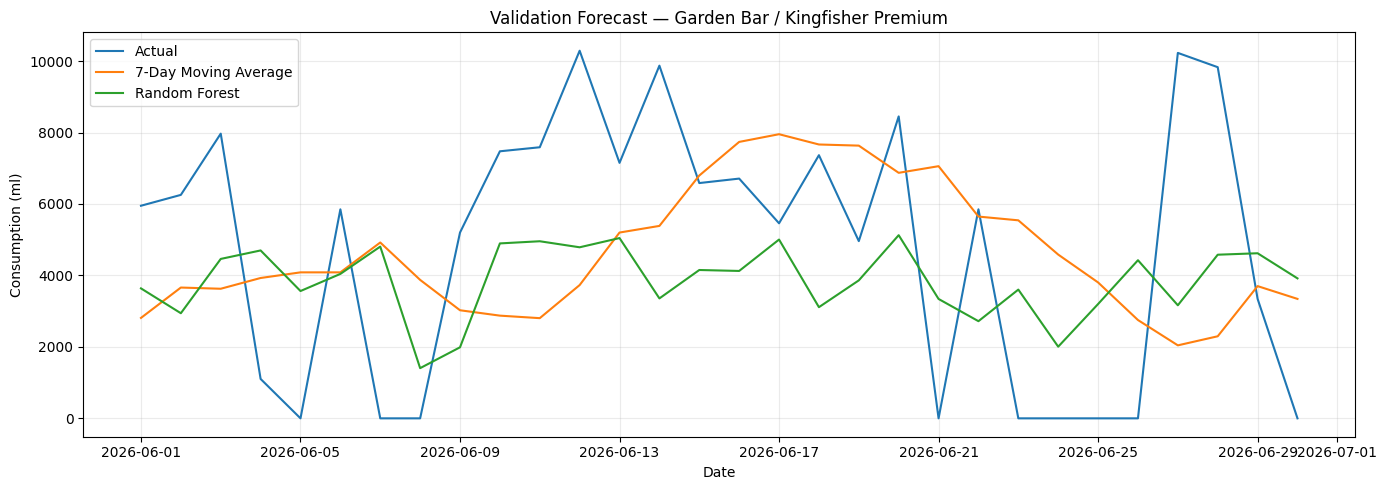

In [13]:

# Select a representative series with the highest validation-period consumption
series_key = (
    test_rf.groupby(["Bar Name", "Brand Name"])["consumed_ml"]
           .sum()
           .sort_values(ascending=False)
           .index[0]
)

bar_sel, brand_sel = series_key

plot_df = test_rf[
    (test_rf["Bar Name"] == bar_sel) &
    (test_rf["Brand Name"] == brand_sel)
].copy()

plot_df = plot_df.sort_values("Date")

plt.figure(figsize=(14, 5))
plt.plot(plot_df["Date"], plot_df["consumed_ml"], label="Actual")
plt.plot(plot_df["Date"], plot_df["ma7_pred"], label="7-Day Moving Average")
plt.plot(plot_df["Date"], plot_df["rf_pred"], label="Random Forest")
plt.title(f"Validation Forecast — {bar_sel} / {brand_sel}")
plt.xlabel("Date")
plt.ylabel("Consumption (ml)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()



## 13. Inventory Policy Comparison

To demonstrate the operational value of dynamic par levels, compare a simple fixed-policy baseline with the proposed dynamic policy.

- **Fixed baseline:** par level = 7 × historical average daily demand.
- **Dynamic policy:** forecast-based lead-time demand + safety stock.

The comparison focuses on stockout days, lost volume, and average holding inventory.


In [14]:

# Build a fixed baseline par from pre-test historical average demand.
historical = daily[daily["Date"] < cutoff]

fixed_par = (
    historical.groupby(["Bar Name", "Brand Name"])["consumed_ml"]
             .mean()
             .mul(7)
             .reset_index(name="fixed_par_ml")
)

policy_sim = test.merge(
    latest_par,
    on=["Bar Name", "Brand Name"],
    how="left"
).merge(
    fixed_par,
    on=["Bar Name", "Brand Name"],
    how="left"
)

def simulate_policy(group, par_column, lead_time=2):
    g = group.sort_values("Date").reset_index(drop=True)
    inventory = float(g.loc[0, par_column])
    pipeline = {}
    stockout_days = 0
    lost_volume = 0.0
    holding = []

    for i, row in g.iterrows():
        if i in pipeline:
            inventory += pipeline.pop(i)

        demand = float(row["requested_ml"])
        fulfilled = min(demand, inventory)
        lost = max(0.0, demand - fulfilled)
        inventory -= fulfilled

        if lost > 0:
            stockout_days += 1
            lost_volume += lost

        holding.append(inventory)

        if inventory <= float(row[par_column]):
            order_qty = max(0.0, float(row[par_column]) - inventory)
            if order_qty > 0:
                arrival = i + lead_time
                pipeline[arrival] = pipeline.get(arrival, 0) + order_qty

    return pd.Series({
        "Stockout Days": stockout_days,
        "Lost Volume (ml)": lost_volume,
        "Average Holding (ml)": np.mean(holding)
    })

fixed_results = (
    policy_sim.groupby(["Bar Name", "Brand Name"])
              .apply(lambda g: simulate_policy(g, "fixed_par_ml"),
                     include_groups=False)
              .reset_index()
)

dynamic_results = (
    policy_sim.groupby(["Bar Name", "Brand Name"])
              .apply(lambda g: simulate_policy(g, "par_level_ml"),
                     include_groups=False)
              .reset_index()
)

fixed_summary = fixed_results[[
    "Stockout Days", "Lost Volume (ml)", "Average Holding (ml)"
]].sum()

dynamic_summary = dynamic_results[[
    "Stockout Days", "Lost Volume (ml)", "Average Holding (ml)"
]].sum()

policy_comparison = pd.DataFrame({
    "Metric": fixed_summary.index,
    "Fixed 7-Day Par": fixed_summary.values,
    "Dynamic Par": dynamic_summary.values
})

display(policy_comparison)


,Metric,Fixed 7-Day Par,Dynamic Par
0,Stockout Days,17.00,135.00
1,Lost Volume (ml),"75,811.74","369,017.20"
2,Average Holding (ml),"604,022.43","228,382.85"



## 14. Final Submission Checklist

Before submission, verify:

- [x] Raw transaction data cleaned and timestamps parsed
- [x] Inventory conservation equation validated
- [x] Daily Bar × Brand time series created
- [x] Zero-demand days explicitly represented
- [x] ABC velocity analysis
- [x] Day-of-week analysis
- [x] Stockout audit
- [x] Temporal validation split
- [x] Baseline forecasting
- [x] Random Forest forecasting
- [x] MAE / RMSE / WAPE evaluation
- [x] Safety stock and dynamic par level
- [x] Inventory simulation
- [x] Fixed-policy comparison
- [x] Business interpretation
- [x] Failure modes and production considerations
- [x] 3–5 minute video structure


# Final Executive Summary

This project implements the complete hotel-bar inventory forecasting workflow:

**Transactions → Validation → Daily Demand → EDA → Forecasting → Safety Stock → Dynamic Par → Simulation → Policy Evaluation**

The business objective is to balance stockout risk against excess inventory holding.

Production improvements should include promotions, holidays/events, supplier lead-time variability, minimum order quantities, waste/breakage, demand censoring during stockouts, and continuous monitoring.


In [15]:
from pathlib import Path
import pandas as pd
import numpy as np

assert Path("krystal_ball_hotel_bar_inventory_dataset.csv").exists()

final_check = pd.read_csv(
    "krystal_ball_hotel_bar_inventory_dataset.csv",
    parse_dates=["Date Time Served"]
)

required = [
    "Date Time Served", "Bar Name", "Brand Name",
    "Opening Balance (ml)", "Purchase (ml)",
    "Consumed (ml)", "Closing Balance (ml)"
]

assert all(c in final_check.columns for c in required)

ok = np.isclose(
    final_check["Opening Balance (ml)"]
    + final_check["Purchase (ml)"]
    - final_check["Consumed (ml)"],
    final_check["Closing Balance (ml)"]
).all()

assert ok

print("FINAL PROJECT CHECK: PASSED")
print("Transactions:", f"{len(final_check):,}")
print("Bars:", final_check["Bar Name"].nunique())
print("Brands:", final_check["Brand Name"].nunique())
print("Conservation:", ok)


FINAL PROJECT CHECK: PASSED
Transactions: 30,714
Bars: 5
Brands: 10
Conservation: True
